# Health Insurance Coverage Gap Analysis and Machine Learning Model for Medicaid Expansion Impact

**In short:** between 2014 and 2023, 40 states and DC expanded Medicaid so that adults earning up to 138% of the
poverty line could get free coverage. This notebook measures what happened to the share of low-income adults
without health insurance, how much of the drop the policy itself caused, and which places would gain the most
if the remaining states expanded.

* **Part 1, analytics:** trends, gaps between states, counties, income, rural areas and race (PostgreSQL views).
* **Part 2, causal effect and machine learning:** results of `05_causal_effects.py` (difference-in-differences)
  and `06_ml_county_effects.py` (causal forest).

Data: Census Small Area Health Insurance Estimates (SAHIE) 2008-2023 for 3,143 counties; KFF expansion dates;
Census poverty, income and population estimates; USDA rural-urban codes. Main outcome: the uninsured rate of
adults 18-64 with income at or below 138% of the federal poverty level (the group expansion made eligible).

In [1]:
import json, warnings
from importlib import import_module
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg
from IPython.display import Image, display
from matplotlib.collections import PolyCollection

import viz_style as vs

warnings.filterwarnings("ignore")
vs.apply()
pd.set_option("display.float_format", "{:,.1f}".format)
ROOT = Path.cwd().parent
CONNINFO = import_module("02_load_postgres").CONNINFO
conn = psycopg.connect(CONNINFO)

def q(sql):
    cur = conn.execute(sql)
    return pd.DataFrame(cur.fetchall(), columns=[c.name for c in cur.description])

## Part 1: Analytics

### 1. The uninsured rate fell everywhere, but much faster where Medicaid expanded

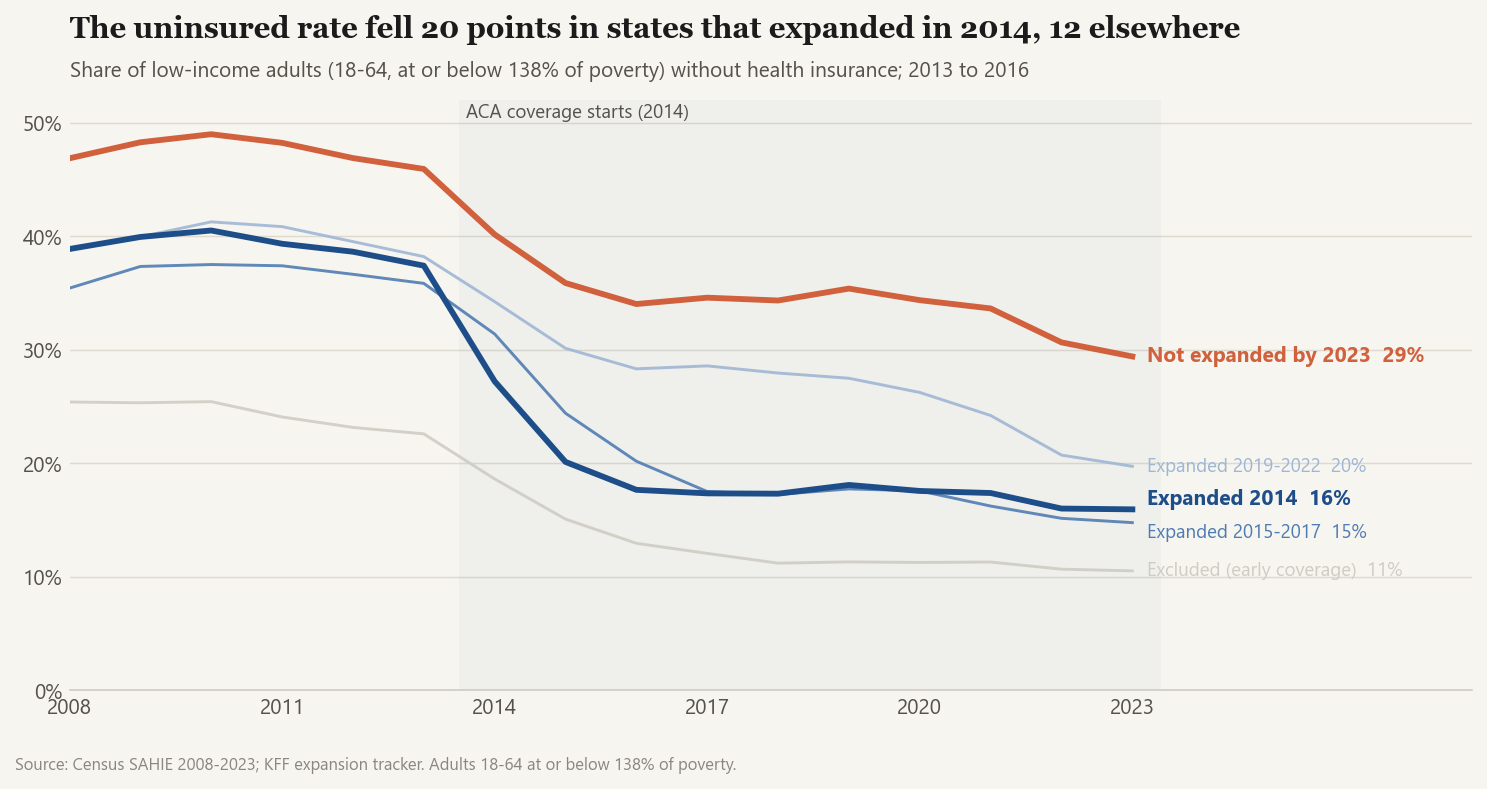

analysis_group,Excluded (early coverage),Expanded 2014,Expanded 2015-2017,Expanded 2019-2022,Not expanded by 2023
year,,,,,
2008,25.4,38.9,35.4,38.8,46.9
2013,22.6,37.4,35.9,38.2,45.9
2014,18.6,27.2,31.4,34.2,40.2
2016,13.0,17.7,20.2,28.3,34.0
2019,11.3,18.1,17.8,27.5,35.4
2023,10.5,16.0,14.8,19.7,29.4


In [2]:
trend = q("SELECT * FROM analytics.v_group_trend ORDER BY year")
trend["pct_uninsured"] = trend.pct_uninsured.astype(float)
wide = trend.pivot(index="year", columns="analysis_group", values="pct_uninsured")

fig, ax = plt.subplots(figsize=(10, 5))
ax.axvspan(2013.5, 2023.4, color=vs.NAVY, alpha=0.035, lw=0)
for grp, col in vs.GROUP_COLORS.items():
    main = grp in ("Expanded 2014", "Not expanded by 2023")
    ax.plot(wide.index, wide[grp], color=col, lw=2.8 if main else 1.4, alpha=1 if main else 0.9, zorder=3 if main else 2)
    nudge = {"Expanded 2014": 0.9, "Expanded 2015-2017": -0.9}.get(grp, 0)
    ax.text(2023.2, wide[grp].iloc[-1] + nudge, f"{grp}  {wide[grp].iloc[-1]:.0f}%", color=col, va="center",
            fontsize=10 if main else 9, fontweight="bold" if main else "normal")
ax.text(2013.6, 50.5, "ACA coverage starts (2014)", color=vs.INK_2, fontsize=9)
ax.set_xlim(2008, 2027.8)
ax.set_xticks(range(2008, 2024, 3))
drop_e = wide.loc[2013, "Expanded 2014"] - wide.loc[2016, "Expanded 2014"]
drop_n = wide.loc[2013, "Not expanded by 2023"] - wide.loc[2016, "Not expanded by 2023"]
ax.set_ylim(0, 52)
vs.pct(ax)
vs.title(ax, f"The uninsured rate fell {drop_e:.0f} points in states that expanded in 2014, {drop_n:.0f} elsewhere",
         "Share of low-income adults (18-64, at or below 138% of poverty) without health insurance; 2013 to 2016")
vs.source(fig)
vs.save(fig, "01_uninsured_trend_by_group")
display(Image(vs.IMAGE_DIR / "01_uninsured_trend_by_group.png"))
wide.loc[[2008, 2013, 2014, 2016, 2019, 2023]].round(1)

### 2. Where the coverage gap is today (2023, every county)

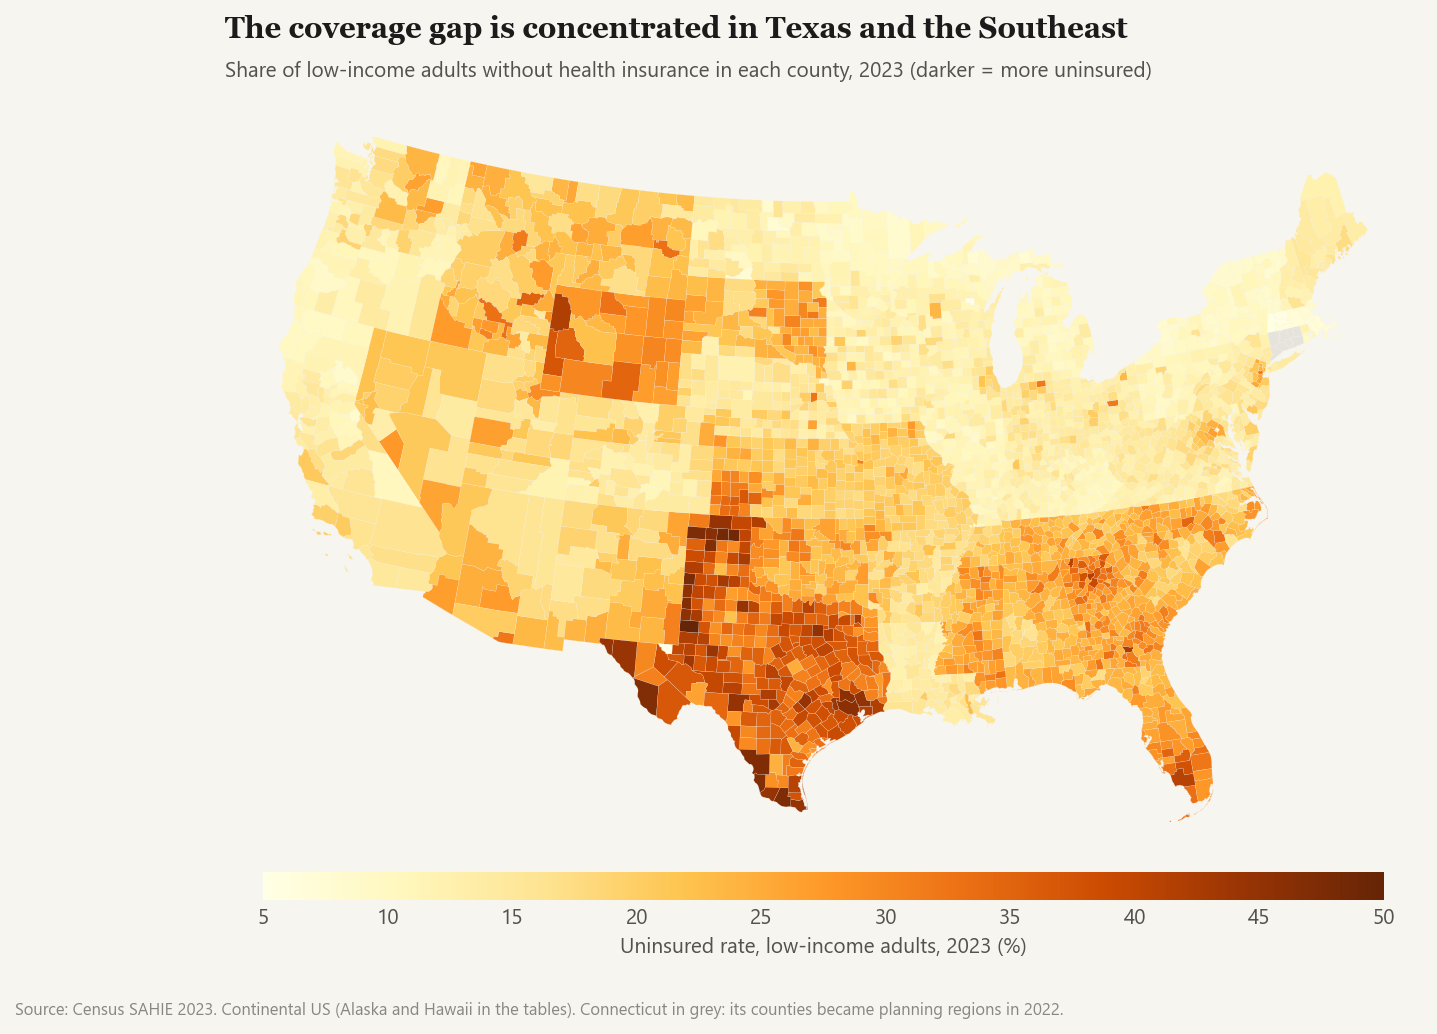

In [3]:
geo = json.loads((ROOT / "Data" / "raw" / "geojson-counties-fips.json").read_text())
gap = q("SELECT county_fips, pct_uninsured::float AS rate FROM core.fact_county_coverage "
        "WHERE year = 2023 AND agecat = 1 AND iprcat = 3").set_index("county_fips")["rate"]
states = q("SELECT state_fips, state_abbrev, analysis_group FROM core.dim_state")

def albers(lon, lat, lon0=-96, lat0=37.5, p1=29.5, p2=45.5):
    lon, lat, lon0, lat0, p1, p2 = map(np.radians, (lon, lat, lon0, lat0, p1, p2))
    n = (np.sin(p1) + np.sin(p2)) / 2
    c = np.cos(p1) ** 2 + 2 * n * np.sin(p1)
    rho = np.sqrt(c - 2 * n * np.sin(lat)) / n
    rho0 = np.sqrt(c - 2 * n * np.sin(lat0)) / n
    return rho * np.sin(n * (lon - lon0)), rho0 - rho * np.cos(n * (lon - lon0))

polys, vals = [], []
for f in geo["features"]:
    fips = {"46113": "46102"}.get(f["id"], f["id"])     # Shannon County SD is now Oglala Lakota (46102)
    if fips[:2] in ("02", "15", "72"):          # continental US only (Alaska, Hawaii shown in tables)
        continue
    g = f["geometry"]
    rings = [g["coordinates"]] if g["type"] == "Polygon" else g["coordinates"]
    for poly in rings:
        xy = np.array(poly[0])
        x, y = albers(xy[:, 0], xy[:, 1])
        polys.append(np.column_stack([x, y]))
        vals.append(gap.get(fips, np.nan))
vals = np.array(vals, dtype=float)

fig, ax = plt.subplots(figsize=(11, 6.6))
cmap = plt.get_cmap("YlOrBr").copy()
cmap.set_bad("#e6e3dc")
pc = PolyCollection(polys, array=np.ma.masked_invalid(vals), cmap=cmap, edgecolors=vs.PAPER, linewidths=0.08)
pc.set_clim(5, 50)
ax.add_collection(pc)
ax.autoscale_view()
ax.set_aspect("equal")
ax.axis("off")
cb = fig.colorbar(pc, ax=ax, orientation="horizontal", fraction=0.035, pad=0.02, aspect=40)
cb.set_label("Uninsured rate, low-income adults, 2023 (%)", color=vs.INK_2)
cb.outline.set_visible(False)
vs.title(ax, "The coverage gap is concentrated in Texas and the Southeast",
         "Share of low-income adults without health insurance in each county, 2023 (darker = more uninsured)")
vs.source(fig, "Source: Census SAHIE 2023. Continental US (Alaska and Hawaii in the tables). Connecticut in grey: its counties became planning regions in 2022.")
vs.save(fig, "02_county_map_2023")
display(Image(vs.IMAGE_DIR / "02_county_map_2023.png"))

### 3. State scorecard: highest uninsured rates today and biggest drops since 2013

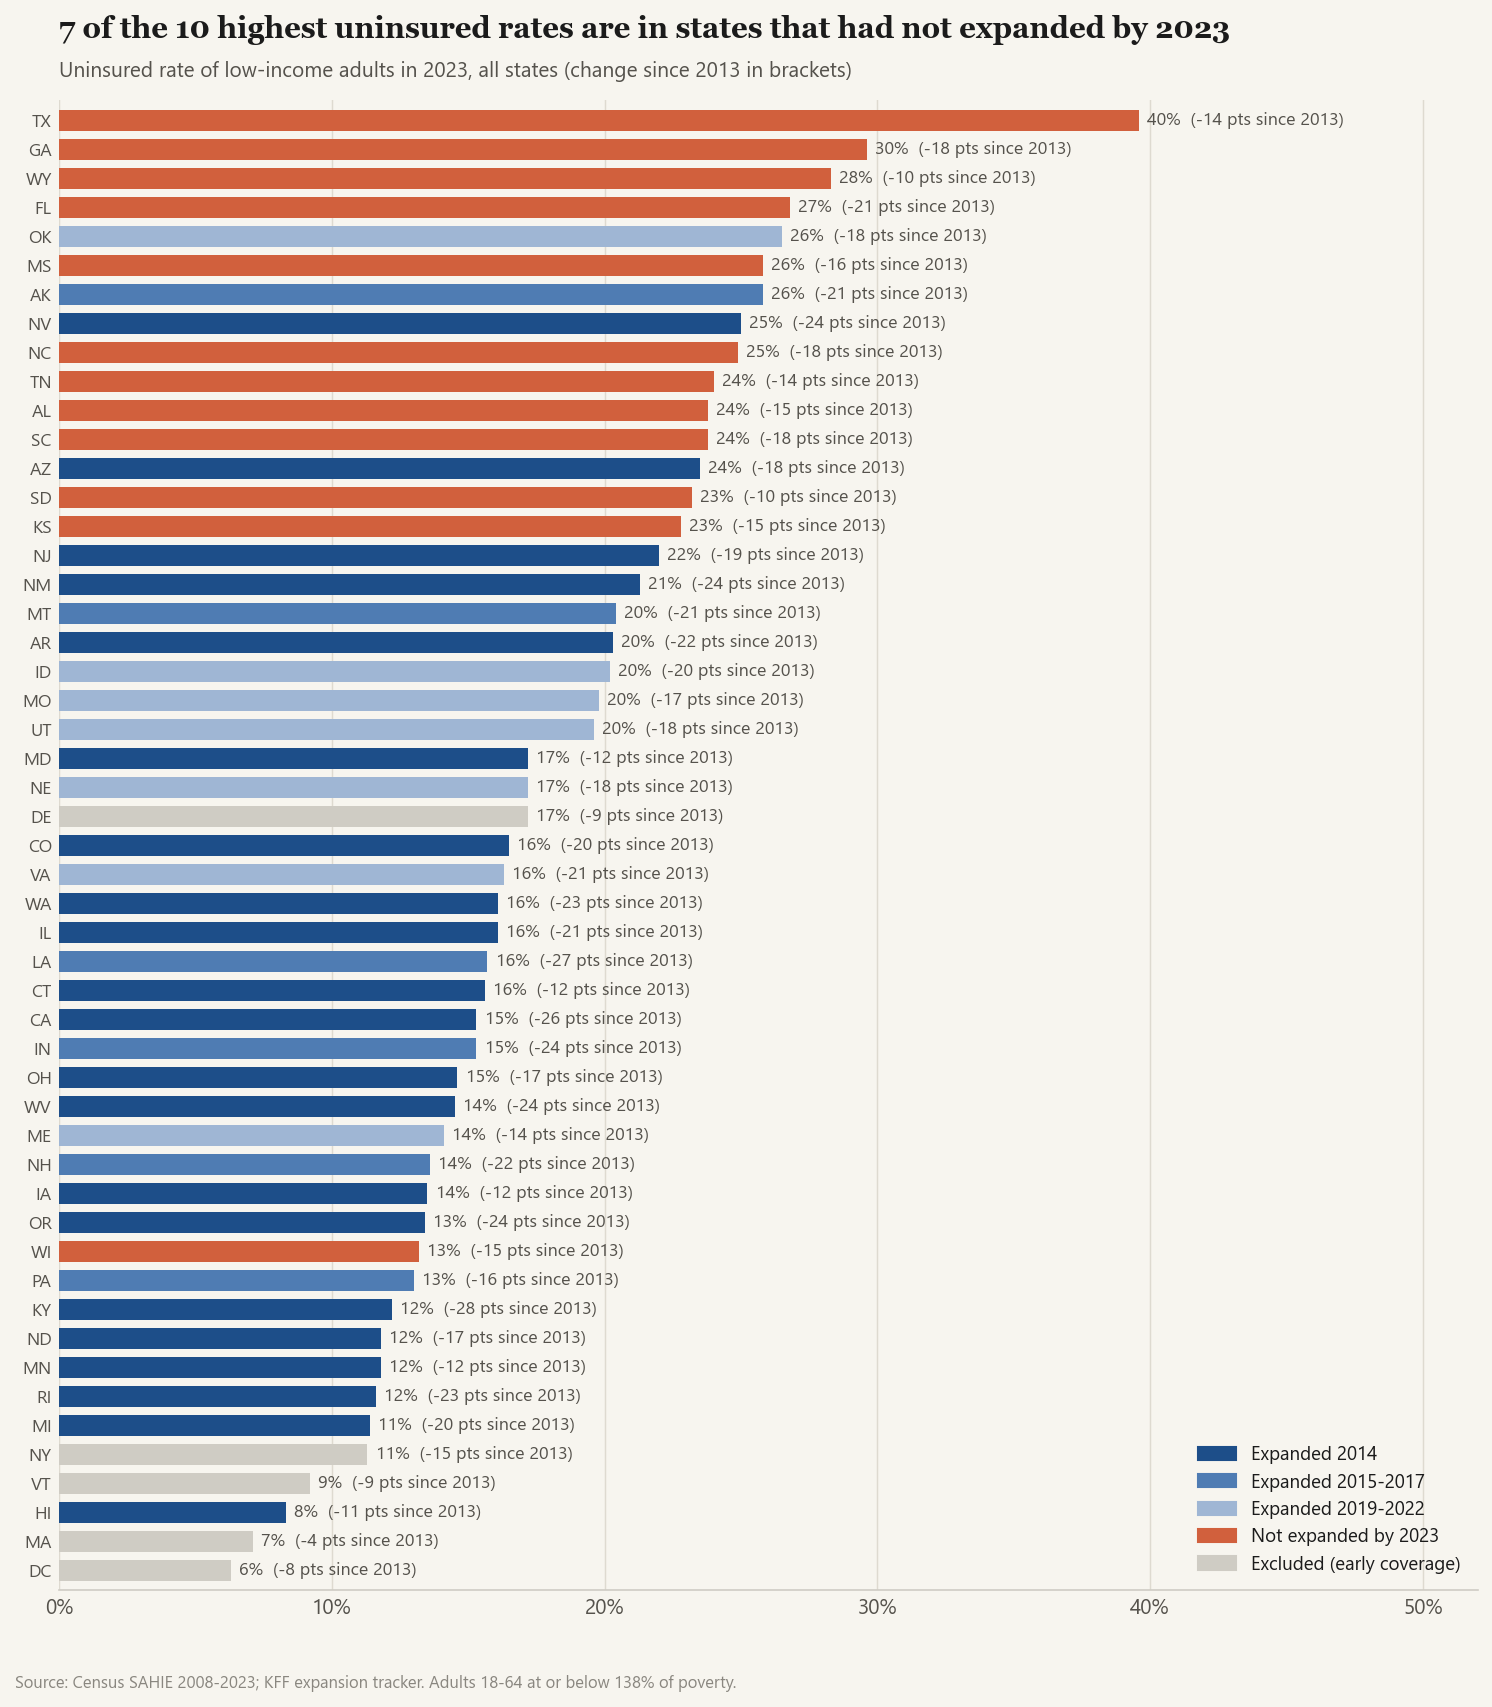

,state_abbrev,analysis_group,pct_2013,pct_2023,change_2013_2023
0,TX,Not expanded by 2023,54.1,39.6,-14.5
1,GA,Not expanded by 2023,47.7,29.6,-18.1
2,WY,Not expanded by 2023,38.0,28.3,-9.7
3,FL,Not expanded by 2023,47.5,26.8,-20.7
4,OK,Expanded 2019-2022,44.4,26.5,-17.9
5,AK,Expanded 2015-2017,47.0,25.8,-21.2
6,MS,Not expanded by 2023,42.2,25.8,-16.4
7,NV,Expanded 2014,49.1,25.0,-24.1
8,NC,Not expanded by 2023,43.4,24.9,-18.5
9,TN,Not expanded by 2023,38.1,24.0,-14.1


In [4]:
sc = q("SELECT * FROM analytics.v_state_scorecard WHERE in_study OR analysis_group LIKE 'Excluded%' ORDER BY pct_2023 DESC")
for c in ["pct_2013", "pct_2016", "pct_2023", "change_2013_2023"]:
    sc[c] = sc[c].astype(float)
fig, ax = plt.subplots(figsize=(10, 11))
s = sc.sort_values("pct_2023")
colors = [vs.GROUP_COLORS[g] for g in s.analysis_group]
ax.barh(s.state_abbrev, s.pct_2023, color=colors, height=0.72)
for i, (v, ch) in enumerate(s[["pct_2023", "change_2013_2023"]].values):
    ax.text(v + 0.3, i, f"{v:.0f}%  ({ch:+.0f} pts since 2013)", va="center", fontsize=8.5, color=vs.INK_2)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_ylim(-0.7, len(s) - 0.3)
ax.set_xlim(0, 52)
vs.pct(ax, "x")
ax.tick_params(axis="y", labelsize=8.5)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in vs.GROUP_COLORS.values()]
ax.legend(handles, vs.GROUP_COLORS.keys(), loc="lower right", fontsize=9)
n_top = int((sc.head(10).analysis_group == "Not expanded by 2023").sum())
vs.title(ax, f"{n_top} of the 10 highest uninsured rates are in states that had not expanded by 2023",
         "Uninsured rate of low-income adults in 2023, all states (change since 2013 in brackets)")
vs.source(fig)
vs.save(fig, "03_state_scorecard")
display(Image(vs.IMAGE_DIR / "03_state_scorecard.png"))
sc[["state_abbrev", "analysis_group", "pct_2013", "pct_2023", "change_2013_2023"]].head(10)

### 4. The gap opened for the people expansion made eligible, much less for everyone else

Adults at 138-400% of poverty were not made eligible for Medicaid (they could get Marketplace subsidies in every
state), so the gap between expansion and non-expansion states should widen much less for them.

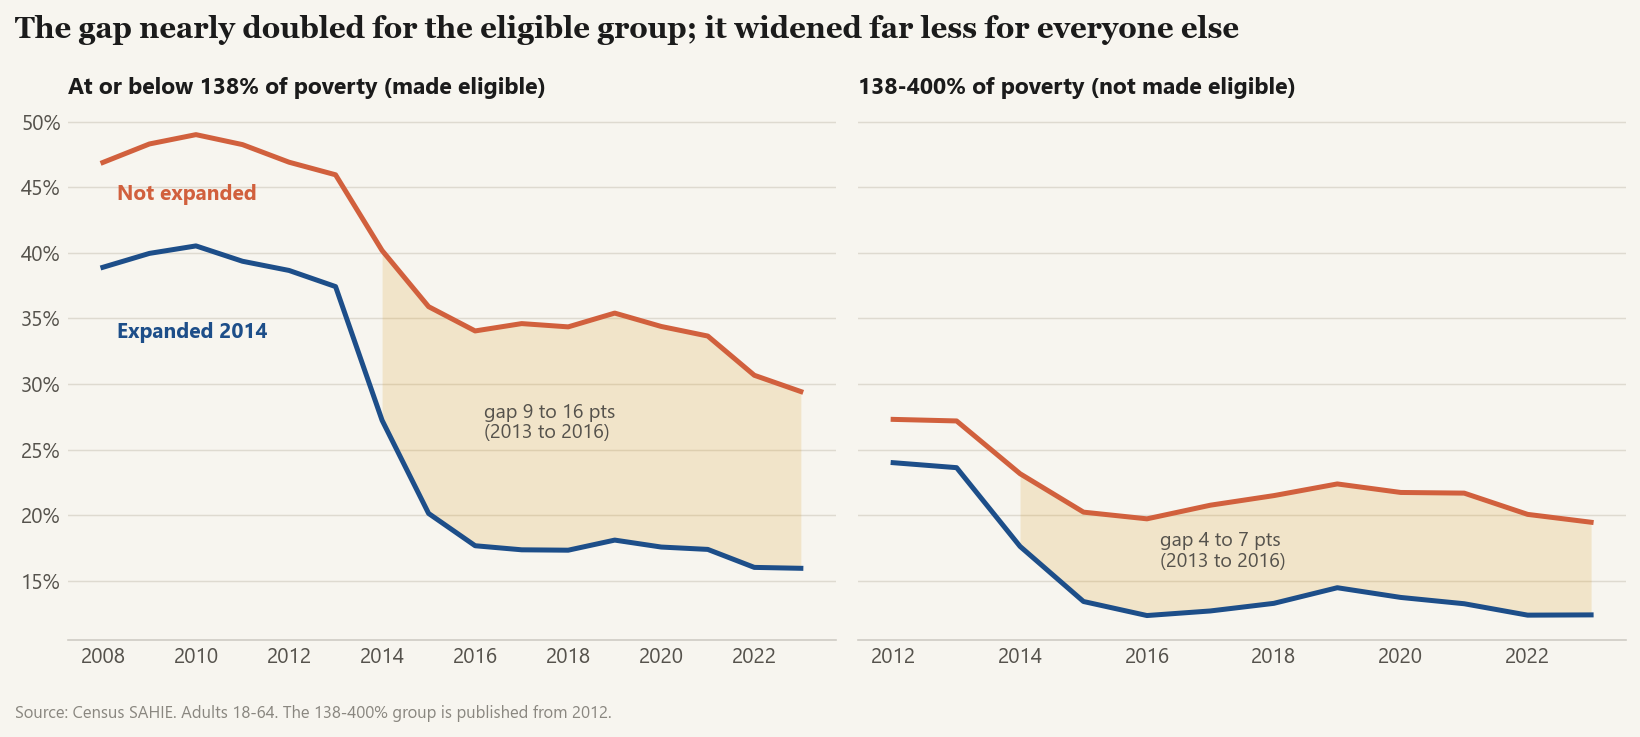

In [5]:
inc = q("SELECT * FROM analytics.v_income_trend WHERE analysis_group IN ('Expanded 2014', 'Not expanded by 2023') ORDER BY year")
inc["pct_uninsured"] = inc.pct_uninsured.astype(float)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax, (ipr, label) in zip(axes, [(3, "At or below 138% of poverty (made eligible)"), (5, "138-400% of poverty (not made eligible)")]):
    d = inc[inc.iprcat == ipr].pivot(index="year", columns="analysis_group", values="pct_uninsured")
    for grp in ["Expanded 2014", "Not expanded by 2023"]:
        ax.plot(d.index, d[grp], color=vs.GROUP_COLORS[grp], lw=2.4)
    ax.fill_between(d.index, d["Expanded 2014"], d["Not expanded by 2023"], where=d.index >= 2014, color=vs.GOLD, alpha=0.18, lw=0)
    gap13 = d.loc[2013, "Not expanded by 2023"] - d.loc[2013, "Expanded 2014"]
    gap16 = d.loc[2016, "Not expanded by 2023"] - d.loc[2016, "Expanded 2014"]
    ax.set_title(label, fontsize=11, loc="left", pad=8)
    ax.text(2016.2, (d.loc[2016].mean()), f"gap {gap13:.0f} to {gap16:.0f} pts\n(2013 to 2016)", color=vs.INK_2, fontsize=9.5)
    vs.pct(ax)
axes[0].text(2008.3, 44, "Not expanded", color=vs.ORANGE, fontweight="bold")
axes[0].text(2008.3, 33.5, "Expanded 2014", color=vs.NAVY, fontweight="bold")
fig.suptitle("The gap nearly doubled for the eligible group; it widened far less for everyone else", x=0.01, ha="left",
             fontfamily="Georgia", fontweight="bold", fontsize=14)
vs.source(fig, "Source: Census SAHIE. Adults 18-64. The 138-400% group is published from 2012.")
vs.save(fig, "04_income_groups")
display(Image(vs.IMAGE_DIR / "04_income_groups.png"))

### 5. Rural and metro counties, race and ethnicity

In [6]:
rural = q(open(ROOT / "SQL" / "05_business_questions.sql", encoding="utf-8-sig").read().split("-- Q7:")[1].split("-- Q8:")[0].split("\n", 1)[1])
rural

,rurality,analysis_group,counties,pct_2013,pct_2023,change_pts
0,Metro,Expanded 2014,388,38.08,16.33,-21.75
1,Metro,Not expanded by 2023,415,46.99,30.25,-16.74
2,Remote rural,Expanded 2014,355,35.47,13.56,-21.91
3,Remote rural,Not expanded by 2023,313,41.78,26.30,-15.48
4,"Rural, near a metro",Expanded 2014,335,33.95,13.92,-20.03
5,"Rural, near a metro",Not expanded by 2023,408,41.33,25.51,-15.82


In [7]:
race = q(open(ROOT / "SQL" / "05_business_questions.sql", encoding="utf-8-sig").read().split("-- Q8:")[1].split("-- Q9:")[0].split("\n", 1)[1])
race

,race_group,analysis_group,pct_2013,pct_2023,change_pts
0,Black (non-Hispanic),Expanded 2014,31.18,12.34,-18.84
1,Black (non-Hispanic),Not expanded by 2023,40.49,22.74,-17.75
2,Hispanic,Expanded 2014,51.81,26.54,-25.27
3,Hispanic,Not expanded by 2023,64.54,45.74,-18.80
4,White (non-Hispanic),Expanded 2014,31.09,11.32,-19.77
5,White (non-Hispanic),Not expanded by 2023,38.11,22.84,-15.27


Remote rural counties had lower rates than big metros to begin with, and all county types in expansion states
fell by about 20-22 points. Hispanic low-income adults have the highest uninsured rates in both groups; in
non-expansion states nearly half (46%) are still uninsured.

## Part 2: How much did expansion itself cause? (difference-in-differences)

The fall in part 1 mixes the effect of expansion with everything else that happened after 2014 (the ACA
Marketplace, a strong economy). `05_causal_effects.py` isolates expansion's effect by comparing each expansion
county's change with the change in similar counties in states that did not expand over the same years
(Callaway & Sant'Anna staggered difference-in-differences, population-weighted, state-clustered bootstrap).

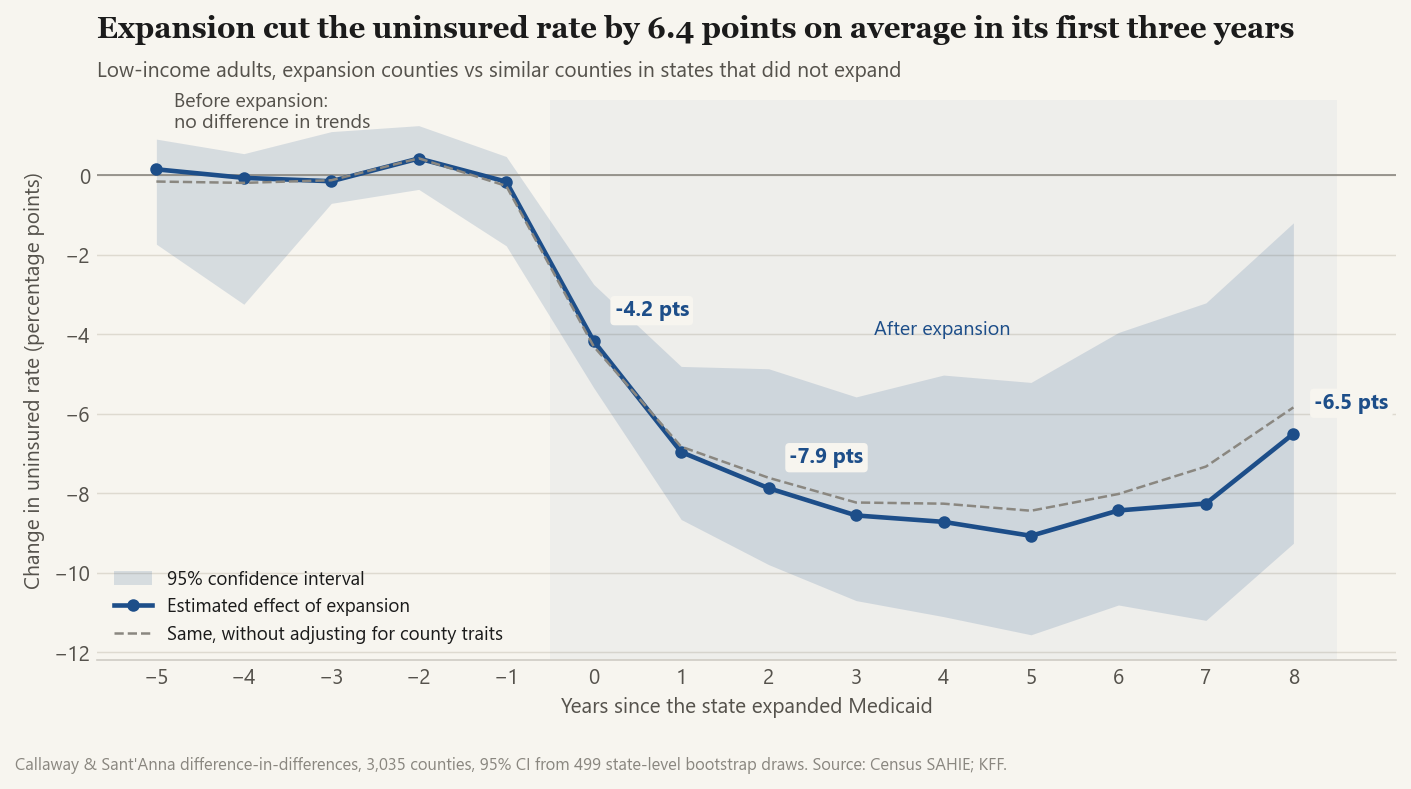

,estimate (pts),95% CI
"Main: covariate-adjusted, years 0-2",-6.4,-7.8 to -4.2
"Unadjusted, years 0-2",-6.3,-8.0 to -4.6
Adults 138-400% FPL (not made eligible),-2.8,-3.9 to -1.4
Placebo: fake 2011 expansion,0.0,-0.8 to 1.4
"Adjusted, all post years",-7.4,
Two-way fixed effects (traditional),-7.1,


In [8]:
cr = json.loads((ROOT / "models" / "causal_results.json").read_text())
display(Image(vs.IMAGE_DIR / "05_event_study.png"))
pd.DataFrame({
    "estimate (pts)": [cr["adjusted"]["att_years_0_2"], cr["unadjusted"]["att_years_0_2"], cr["placebo_138_400"]["att_years_0_2"],
                       cr["placebo_fake_2011"]["att"], cr["adjusted"]["att_all_post_years"], cr["twfe"]],
    "95% CI": [f"{a:.1f} to {b:.1f}" for a, b in [cr["adjusted"]["ci"], cr["unadjusted"]["ci"], cr["placebo_138_400"]["ci"],
                                                  cr["placebo_fake_2011"]["ci"]]] + ["", ""],
}, index=["Main: covariate-adjusted, years 0-2", "Unadjusted, years 0-2", "Adults 138-400% FPL (not made eligible)",
          "Placebo: fake 2011 expansion", "Adjusted, all post years", "Two-way fixed effects (traditional)"])

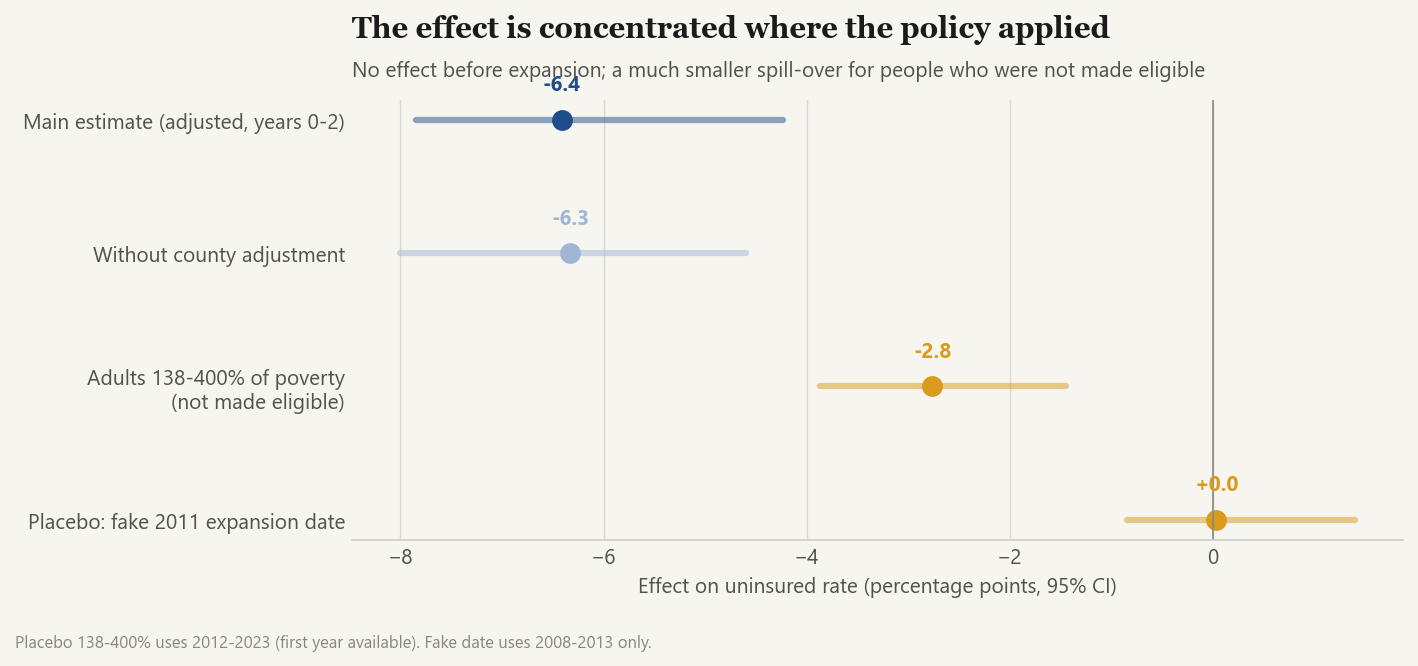

Low-income adults with coverage in 2023 because of expansion (study states): 968,009 (95% CI 236,664 to 1,286,218)


In [9]:
display(Image(vs.IMAGE_DIR / "06_robustness_checks.png"))
print(f"Low-income adults with coverage in 2023 because of expansion (study states): "
      f"{cr['people_covered_2023']['estimate']:,.0f} (95% CI {cr['people_covered_2023']['ci'][0]:,.0f} to {cr['people_covered_2023']['ci'][1]:,.0f})")

## Part 3: Machine learning: which counties gain the most? (causal forest)

`06_ml_county_effects.py` trains a causal forest (EconML, double machine learning) on every expansion wave from
2014 to 2021, compared with counties in states that did not expand over the same years. It estimates a separate
effect for each county from its pre-expansion traits, and is checked two ways: its average must agree with the
difference-in-differences estimate, and on states held out of training, counties predicted to gain more must
really have gained more.

Causal forest average effect on expansion counties: -6.46 pts (difference-in-differences: -6.41 pts)


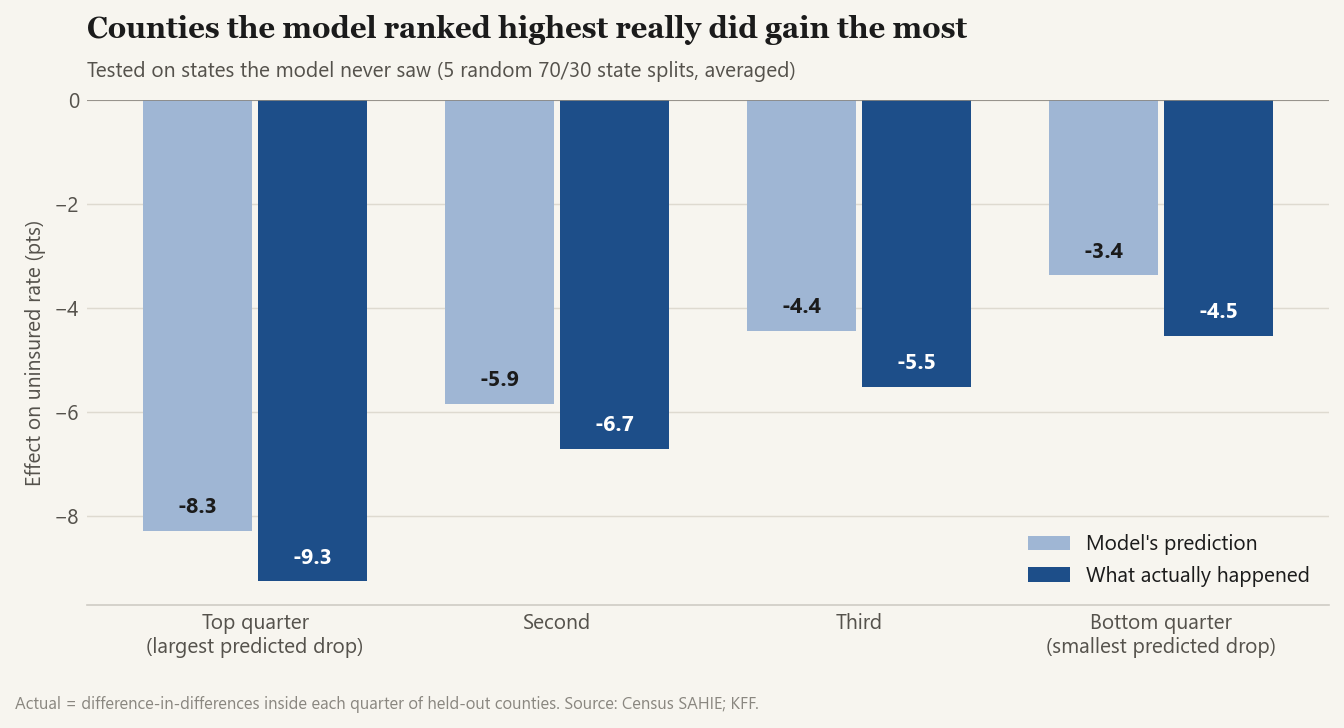

,split,gap_top_vs_bottom_predicted,gap_top_vs_bottom_actual
0,0,-6.7,-3.6
1,1,-5.4,-9.0
2,2,-4.9,1.0
3,3,-2.4,-5.2
4,4,-4.1,-6.8


In [10]:
mr = json.loads((ROOT / "models" / "ml_results.json").read_text())
print(f"Causal forest average effect on expansion counties: {mr['forest_ate_expansion_counties']:.2f} pts "
      f"(difference-in-differences: {mr['did_estimate_years_0_2']:.2f} pts)")
display(Image(vs.IMAGE_DIR / "07_model_validation.png"))
pd.DataFrame(mr["validation_splits"])[["split", "gap_top_vs_bottom_predicted", "gap_top_vs_bottom_actual"]]

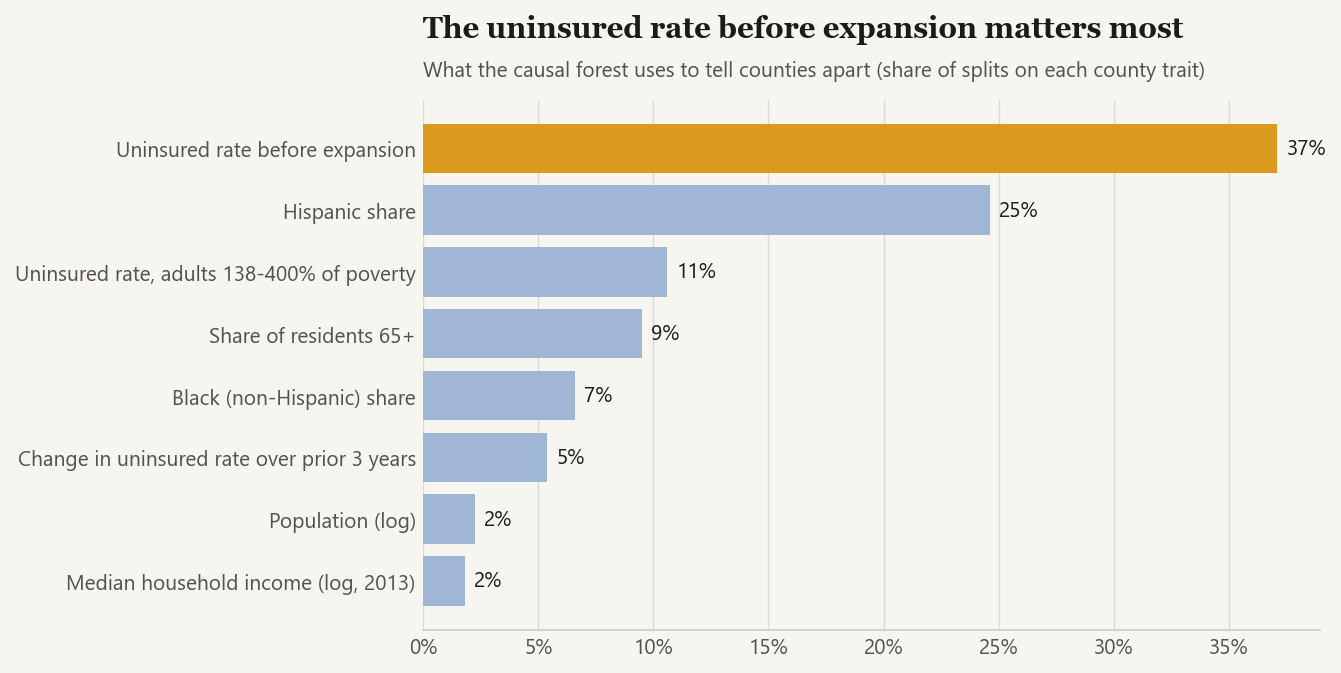

,Metro,Remote rural,"Rural, near a metro",Lowest poverty,Low-mid,Mid-high,Highest poverty,Lowest,Highest
rurality,-6.4,-7.3,-6.6,NaN,NaN,NaN,NaN,NaN,NaN
poverty_band,NaN,NaN,NaN,-5.5,-5.6,-6.9,-7.0,NaN,NaN
base_band,NaN,NaN,NaN,NaN,-5.1,-6.1,NaN,-4.0,-8.2


In [11]:
display(Image(vs.IMAGE_DIR / "08_effect_drivers.png"))
pd.DataFrame(mr["effect_by"]).T

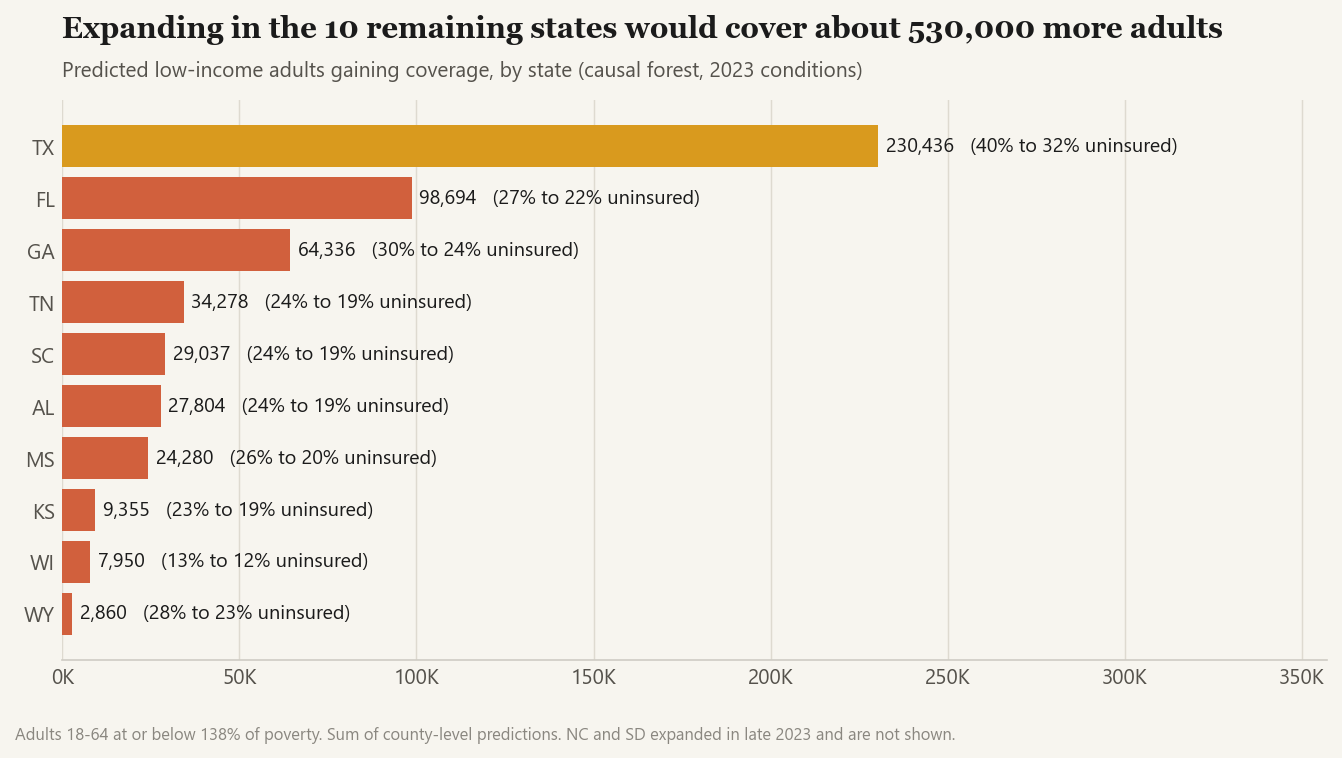

,county_name,state,rurality,base_rate,predicted_effect_pts,effect_lo,effect_hi,adults_gaining_coverage
0,Harris County,TX,Metro,45.7,-7.0,-10.3,-3.7,"40,248.5"
1,Dallas County,TX,Metro,45.1,-7.0,-10.0,-3.9,"19,709.7"
2,Bexar County,TX,Metro,35.3,-7.5,-10.1,-4.8,"18,153.8"
3,Miami-Dade County,FL,Metro,27.7,-5.5,-8.8,-2.2,"16,165.6"
4,Hidalgo County,TX,Metro,47.3,-9.3,-12.4,-6.3,"14,723.4"
5,Tarrant County,TX,Metro,39.9,-6.2,-7.7,-4.8,"12,324.6"
6,El Paso County,TX,Metro,44.3,-9.8,-12.1,-7.6,"11,998.9"
7,Cameron County,TX,Metro,44.7,-11.4,-13.4,-9.4,"8,062.1"
8,Broward County,FL,Metro,27.9,-4.0,-5.0,-2.9,"6,989.7"
9,Travis County,TX,Metro,30.6,-5.5,-6.7,-4.4,"6,662.7"


In [12]:
display(Image(vs.IMAGE_DIR / "09_nonexpansion_predictions.png"))
top = pd.read_csv(ROOT / "Data" / "clean" / "ml_nonexpansion_county_predictions.csv")
top = top[~top.state.isin(["NC", "SD"])]
top.head(15)[["county_name", "state", "rurality", "base_rate", "predicted_effect_pts", "effect_lo", "effect_hi", "adults_gaining_coverage"]]

## Limitations

* SAHIE numbers are model-based estimates with margins of error (median about 4 points for a county's low-income
  adults); models weight counties by population so large, precise counties count more.
* States chose whether to expand. The design removes fixed differences between states and shared yearly
  changes, and pre-expansion trends match, but a state-specific shock at the same time as expansion would still bias
  the estimate.
* SAHIE measures income over a year; Medicaid uses monthly income, so some people above 138% were eligible part
  of the year. This is one reason the 138-400% group shows a small effect.
* Predictions for the remaining states assume expansion would work there as it did in similar counties that
  expanded, under 2023 conditions. They are estimates of the drop in the uninsured rate, not enrollment forecasts.